In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
 ## 📥 Data Loading

df = pd.read_csv("C:/Users/Gunjan Shaw/Downloads/transactions_test.csv")
df.head()

,transaction_id,transaction_time,customer_id,merchant_id,account_age_days,credit_score_band,kyc_level,avg_monthly_spend,merchant_risk_score,transaction_amount,...,device_type,is_international,ip_risk_score,txn_count_1h,txn_count_24h,failed_txn_count_24h,geo_distance_from_last_txn,amount_deviation_from_user_mean,is_fraud,post_auth_risk_score
0,305461,2023-10-01 00:02:41.559131982,11453,7397,1417,4,2,7549.746993,0.056340,1783.564199,...,mobile,0,0.417366,1,2,0,54.226534,1531.905966,0,0.358507
1,341279,2023-10-01 00:06:25.507380194,28021,97,830,2,2,2766.322082,0.736960,7038.755549,...,mobile,0,0.272247,1,3,1,60.728405,6946.544813,0,0.065886
2,344364,2023-10-01 00:07:50.846454903,2269,2796,1651,2,3,3988.151593,0.454618,663.057016,...,mobile,0,0.446442,3,3,0,102.171038,530.118629,0,0.026225
3,84227,2023-10-01 00:17:11.834872052,32373,787,1207,1,2,5472.122178,0.417973,1665.509484,...,desktop,0,0.308703,2,3,0,10.146806,1483.105412,0,0.201940
4,187825,2023-10-01 00:19:50.841780964,13548,4439,1926,5,2,1758.784635,0.535169,1524.306346,...,mobile,1,0.305401,2,1,1,18.328551,1465.680191,0,0.234395


In [8]:
## 🔍 Data Understanding

df.shape

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99887 entries, 0 to 99886
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   transaction_id                   99887 non-null  int64  
 1   transaction_time                 99887 non-null  object 
 2   customer_id                      99887 non-null  int64  
 3   merchant_id                      99887 non-null  int64  
 4   account_age_days                 99887 non-null  int64  
 5   credit_score_band                99887 non-null  int64  
 6   kyc_level                        99887 non-null  int64  
 7   avg_monthly_spend                99887 non-null  float64
 8   merchant_risk_score              99887 non-null  float64
 9   transaction_amount               99887 non-null  float64
 10  payment_channel                  99887 non-null  object 
 11  device_type                      99887 non-null  object 
 12  is_international  

,transaction_id,customer_id,merchant_id,account_age_days,credit_score_band,kyc_level,avg_monthly_spend,merchant_risk_score,transaction_amount,is_international,ip_risk_score,txn_count_1h,txn_count_24h,failed_txn_count_24h,geo_distance_from_last_txn,amount_deviation_from_user_mean,is_fraud,post_auth_risk_score
count,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000
mean,199766.074885,19981.785828,4012.092995,1015.371770,3.001952,2.000861,5010.227368,0.251144,2402.424634,0.070500,0.286149,1.098571,3.193569,0.350396,34.102134,2235.417055,0.019852,0.212751
std,115390.859545,11542.538075,2315.025500,571.352939,1.411934,0.817754,3156.631432,0.146128,1700.928317,0.255989,0.159996,1.047610,1.784554,0.591879,25.616841,1704.310718,0.139494,0.146650
min,0.000000,0.000000,0.000000,30.000000,1.000000,1.000000,43.855387,0.001365,2.582327,0.000000,0.001049,0.000000,0.000000,0.000000,0.000844,-591.254461,0.000000,0.000001
25%,99975.500000,10010.000000,2011.000000,519.000000,2.000000,1.000000,2681.766985,0.136277,1156.397497,0.000000,0.160760,0.000000,2.000000,0.000000,13.740519,988.724336,0.000000,0.101666
50%,200061.000000,19973.000000,4013.000000,1015.000000,3.000000,2.000000,4354.933259,0.229436,2013.834825,0.000000,0.265013,1.000000,3.000000,0.000000,28.939060,1850.656646,0.000000,0.203705
75%,299469.000000,29946.500000,6018.000000,1511.000000,4.000000,3.000000,6684.831846,0.344912,3229.179596,0.000000,0.390788,2.000000,4.000000,1.000000,49.138707,3065.073793,0.000000,0.306216
max,399999.000000,39999.000000,7999.000000,1999.000000,5.000000,3.000000,32362.617533,0.837624,16726.789145,1.000000,0.944763,9.000000,13.000000,6.000000,180.819053,16148.411469,1.000000,0.999988


In [10]:
## 🧹 Data Cleaning

df.isnull().sum()
df.drop_duplicates(inplace=True)

In [11]:
## 🎯 Fraud vs Non-Fraud Analysis


df['is_fraud'].value_counts()

is_fraud
0    97904
1     1983
Name: count, dtype: int64

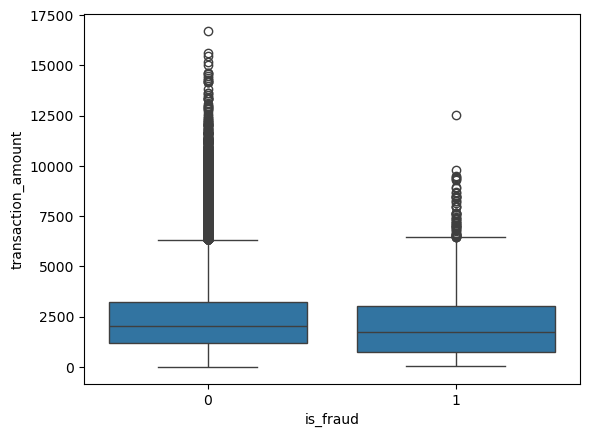

In [12]:
## 📊 Transaction Amount Analysis

sns.boxplot(x='is_fraud', y='transaction_amount', data=df)
plt.show()

In [13]:
## 🏪 Merchant Risk Score Analysis

df.groupby('is_fraud')['merchant_risk_score'].mean()

is_fraud
0    0.250715
1    0.272312
Name: merchant_risk_score, dtype: float64

In [14]:
## ⚡ Transaction Frequency Analysis

df.groupby('is_fraud')['txn_count_1h'].mean()

is_fraud
0    1.094102
1    1.319213
Name: txn_count_1h, dtype: float64

In [15]:
## 🌍 International Transaction Analysis

pd.crosstab(df['is_international'], df['is_fraud'])

is_fraud,0,1
is_international,,
0,91296,1549
1,6608,434


In [16]:
## 📱 Device Type Analysis

pd.crosstab(df['device_type'], df['is_fraud'])

is_fraud,0,1
device_type,,
desktop,24585,499
mobile,68382,1385
tablet,4937,99


In [17]:
## ❌ Failed Transactions Analysis

df.groupby('is_fraud')['failed_txn_count_24h'].mean()

is_fraud
0    0.343592
1    0.686334
Name: failed_txn_count_24h, dtype: float64

In [18]:
## 📍 Location Distance Analysis

df.groupby('is_fraud')['geo_distance_from_last_txn'].mean()

is_fraud
0    34.116447
1    33.395479
Name: geo_distance_from_last_txn, dtype: float64

In [19]:
## 💰 Spending Deviation Analysis

df.groupby('is_fraud')['amount_deviation_from_user_mean'].mean()

is_fraud
0    2240.504005
1    1984.265913
Name: amount_deviation_from_user_mean, dtype: float64

In [21]:
 ## 💳 Payment Channel Analysis

df.groupby('payment_channel')['is_fraud'].mean()

payment_channel
bank_transfer    0.021397
card             0.019803
upi              0.018689
wallet           0.020942
Name: is_fraud, dtype: float64